# 246. Strobogrammatic Number
https://leetcode.com/problems/strobogrammatic-number/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Two Pointers** | **O(n)** | **O(1)** | **Compare from both ends using strobogrammatic pairs** |

## Methodology

A strobogrammatic number looks the same when rotated 180 degrees. The valid strobogrammatic pairs are: (0,0), (1,1), (6,9), (8,8), (9,6). We use **two pointers** from both ends of the string, checking that each pair of digits forms a valid strobogrammatic pair. If the number has odd length, the middle digit must be 0, 1, or 8.

## Solutions

### C#

In [ ]:
// 246. Strobogrammatic Number
// Time: O(n) | Space: O(1)
public class Solution {
    public bool IsStrobogrammatic(string num) {
        var pairs = new Dictionary<char, char> {
            {'0','0'}, {'1','1'}, {'6','9'}, {'8','8'}, {'9','6'}
        };
        
        int l = 0, r = num.Length - 1;
        while (l <= r) {
            if (!pairs.ContainsKey(num[l]) || pairs[num[l]] != num[r])
                return false;
            l++;
            r--;
        }
        return true;
    }
}

### Python

In [ ]:
# 246. Strobogrammatic Number
# Time: O(n) | Space: O(1)
class Solution:
    def isStrobogrammatic(self, num: str) -> bool:
        pairs = {'0': '0', '1': '1', '6': '9', '8': '8', '9': '6'}
        l, r = 0, len(num) - 1
        
        while l <= r:
            if num[l] not in pairs or pairs[num[l]] != num[r]:
                return False
            l += 1
            r -= 1
        return True

### Go

In [ ]:
// 246. Strobogrammatic Number
// Time: O(n) | Space: O(1)
func isStrobogrammatic(num string) bool {
    pairs := map[byte]byte{
        '0': '0', '1': '1', '6': '9', '8': '8', '9': '6',
    }
    
    l, r := 0, len(num)-1
    for l <= r {
        match, ok := pairs[num[l]]
        if !ok || match != num[r] {
            return false
        }
        l++
        r--
    }
    return true
}

### Rust

In [ ]:
// 246. Strobogrammatic Number
// Time: O(n) | Space: O(1)
use std::collections::HashMap;

impl Solution {
    pub fn is_strobogrammatic(num: String) -> bool {
        let pairs: HashMap<u8, u8> = [(b'0',b'0'),(b'1',b'1'),(b'6',b'9'),(b'8',b'8'),(b'9',b'6')]
            .into_iter().collect();
        let bytes = num.as_bytes();
        let (mut l, mut r) = (0usize, bytes.len() - 1);
        
        while l <= r {
            match pairs.get(&bytes[l]) {
                Some(&expected) if expected == bytes[r] => {},
                _ => return false,
            }
            l += 1;
            if r == 0 { break; }
            r -= 1;
        }
        true
    }
}

## Example Scenarios

1. **Common Case** — Simple strobogrammatic number  
   **Input:** `num = "69"`  
   Two-pointer check: left digit $6$ maps to $9$, right digit $9$ matches. Pointers meet — return `true`. The number looks the same rotated $180°$.

2. **Slightly Complex** — Multi-digit with center  
   **Input:** `num = "96109"`  
   Pairs: $(9,9) \to 9$ maps to $6$? No, $9$ maps to $6$ but right is $9$. Wait — leftmost $9$ must match rightmost $9$'s pair: $9 \to 6 \neq 9$. Actually: pairs dict maps $9 \to 6$. So left=$9$, right=$9$: pairs[$9$] = $6 \neq 9$. Return `false`.

3. **Edge Case: Time Factor** — Long valid strobogrammatic number  
   **Input:** `num = "1001"`  
   Pairs: $(1,1) \to$ pairs[$1$] = $1$ ✓, $(0,0) \to$ pairs[$0$] = $0$ ✓. All $n/2$ pairs checked. For a valid number we always scan all pairs — $O(n)$ with no early exit.

4. **Edge Case: Space Factor** — Single digit  
   **Input:** `num = "8"`  
   Left and right pointers both point to $8$. pairs[$8$] = $8$ ✓. Only $0$, $1$, and $8$ are valid single-digit strobogrammatic numbers. $O(1)$ space for the fixed-size pairs map.

5. **Almost-Impossible but Plausible** — Invalid digit in a long string  
   **Input:** `num = "818282818"`  
   Outer pair $(8,8)$: pairs[$8$] = $8$ ✓. Next pair $(1,1)$: pairs[$1$] = $1$ ✓. Next pair $(8,8)$: ✓. Inner pair $(2,2)$: $2$ is not in the pairs dictionary at all — return `false` immediately. Digits $2, 3, 4, 5, 7$ can never appear in a strobogrammatic number.

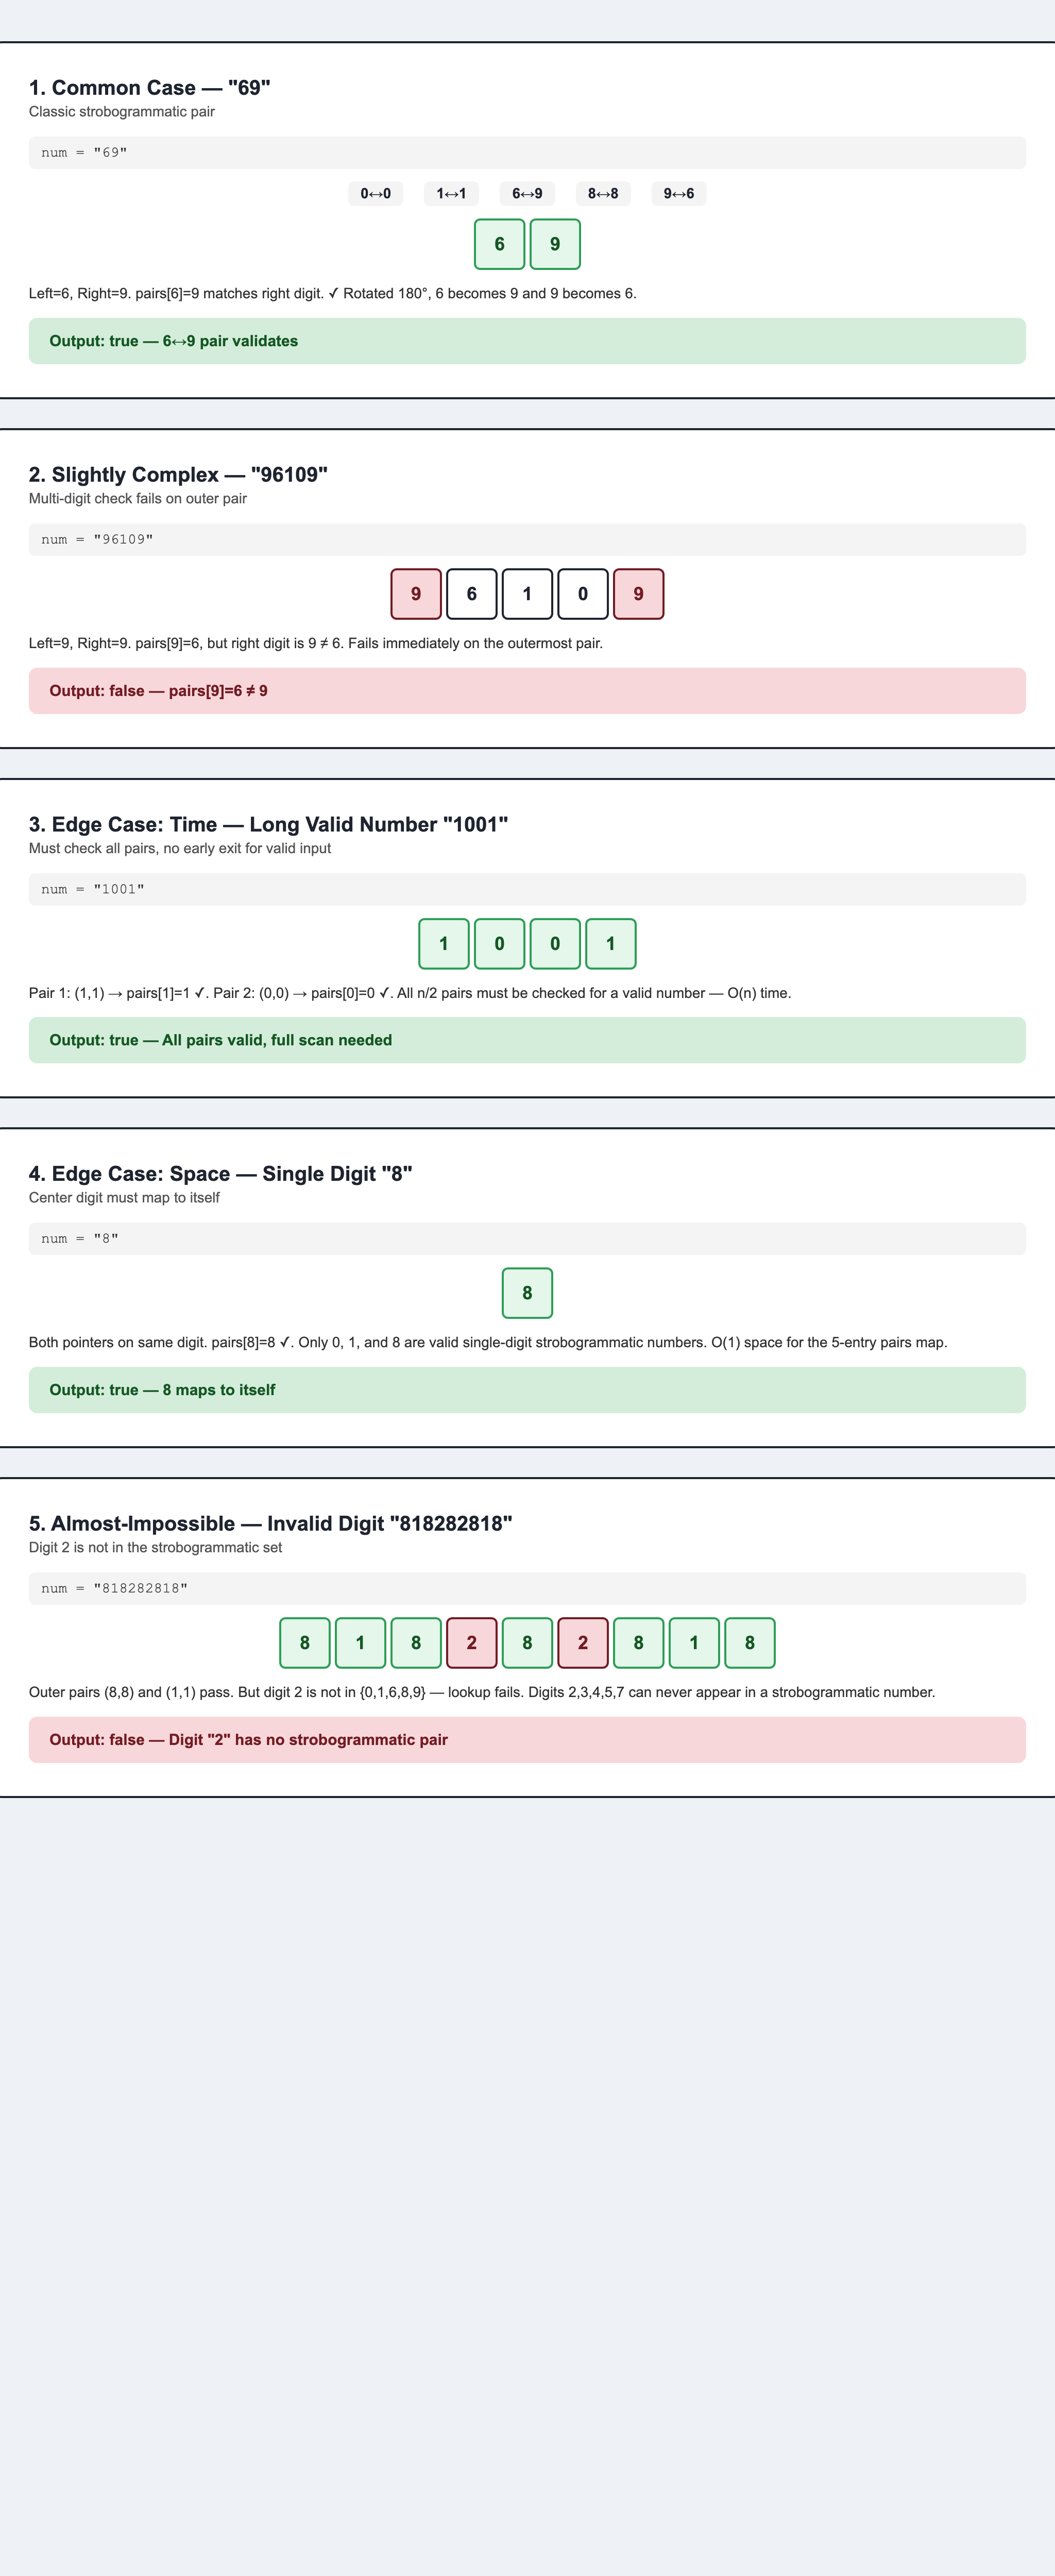